
# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 1 — Project Setup and Raw Data Understanding

This phase prepares the project environment, loads and preserves the raw questionnaire data, documents its structure, checks its initial quality, and produces general raw-data visualisations. **No preprocessing, cleaning, encoding, scaling, feature engineering, or model training is performed in this phase.**



## Phase 1 Output Structure

```text
outputs/
└── Phase_01_Project_Setup_and_Raw_Data_Understanding/
    └── Section_01_XX_Section_Title/
        └── Cell_01_XX_XX_Cell_Title/
            ├── tables/
            ├── figures/
            ├── reports/
            └── files/
```

The final section exports a consolidated Excel workbook, a file manifest, a readable summary, and a ZIP archive of all Phase 1 outputs.



# Section 1.1 — Project Information and Execution Environment

**Description:** Defines the project identity and selects Google Colab, Anaconda, or Visual Studio Code through one fixed variable. It also creates the Phase → Section → Cell output structure.


In [1]:

# Cell 1.1.1 — Select Execution Environment and Create Project Folders

from pathlib import Path
from datetime import datetime
import json
import os
import re
import shutil
import sys

# ================================================================
# CHANGE THIS VARIABLE ONLY
# Allowed values: "COLAB", "ANACONDA", "VSCODE"
# ================================================================
EXECUTION_ENVIRONMENT = "ANACONDA"

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()
ALLOWED_ENVIRONMENTS = {"COLAB", "ANACONDA", "VSCODE"}

if EXECUTION_ENVIRONMENT not in ALLOWED_ENVIRONMENTS:
    raise ValueError(
        f"EXECUTION_ENVIRONMENT must be one of {sorted(ALLOWED_ENVIRONMENTS)}"
    )

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        print("Colab is unavailable in this runtime; a local test folder is used.")
        PROJECT_ROOT = Path.cwd() / "Jaafar_MSc_Thesis"
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_DIR = OUTPUT_ROOT / "Phase_01_Project_Setup_and_Raw_Data_Understanding"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PHASE_DIR.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


def safe_name(text):
    """Convert a title into a safe folder or file name."""
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    """Create Phase / Section / Cell / output-type folders."""
    section_folder = PHASE_DIR / safe_name(
        f"Section_{section_number}_{section_title}"
    )
    cell_folder = section_folder / safe_name(
        f"Cell_{cell_number}_{cell_title}"
    )
    folders = {
        "cell": cell_folder,
        "tables": cell_folder / "tables",
        "figures": cell_folder / "figures",
        "reports": cell_folder / "reports",
        "files": cell_folder / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


CELL_FOLDERS = create_cell_folders(
    "01_01",
    "Project_Information_and_Execution_Environment",
    "01_01_01",
    "Select_Execution_Environment_and_Create_Project_Folders",
)

project_configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "project_root": str(PROJECT_ROOT),
    "data_directory": str(DATA_DIR),
    "phase_directory": str(PHASE_DIR),
    "run_timestamp": RUN_TIMESTAMP,
}

with (CELL_FOLDERS["reports"] / "01_01_01_project_configuration.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(project_configuration, file, ensure_ascii=False, indent=2)

print("Execution environment:", EXECUTION_ENVIRONMENT)
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Phase output directory:", PHASE_DIR)


Execution environment: ANACONDA
Project root: C:\Users\User\Desktop
Data directory: C:\Users\User\Desktop\data
Phase output directory: C:\Users\User\Desktop\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding



# Section 1.2 — Install Required Libraries

**Description:** Checks the libraries needed for Phase 1 and installs only packages that are missing. Existing packages are not reinstalled.


In [2]:

# Cell 1.2.1 — Check and Install Missing Libraries

import importlib.util
import subprocess
import sys

CELL_FOLDERS = create_cell_folders(
    "01_02",
    "Install_Required_Libraries",
    "01_02_01",
    "Check_and_Install_Missing_Libraries",
)

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "openpyxl": "openpyxl",
}

installation_report = []

for import_name, package_name in required_packages.items():
    is_installed = importlib.util.find_spec(import_name) is not None
    if is_installed:
        status = "Already installed"
    else:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package_name]
        )
        status = "Installed during this run"
    installation_report.append(
        {
            "import_name": import_name,
            "package_name": package_name,
            "status": status,
        }
    )

import pandas as pd

installation_report_df = pd.DataFrame(installation_report)
installation_report_df.to_csv(
    CELL_FOLDERS["tables"] / "01_02_01_library_installation_report.csv",
    index=False,
    encoding="utf-8-sig",
)
installation_report_df.to_excel(
    CELL_FOLDERS["tables"] / "01_02_01_library_installation_report.xlsx",
    index=False,
)

display(installation_report_df)


,import_name,package_name,status
0,pandas,pandas,Already installed
1,numpy,numpy,Already installed
2,matplotlib,matplotlib,Already installed
3,openpyxl,openpyxl,Already installed



# Section 1.3 — Import Libraries and Reproducibility Settings

**Description:** Imports the libraries, fixes the random seed, defines supported file formats, and creates simple reusable functions for saving tables, figures, reports, and files.


In [3]:

# Cell 1.3.1 — Import Libraries and Set Reproducibility Options

import json
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("default")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

SUPPORTED_FILE_TYPES = {".csv", ".xlsx", ".xls"}

CELL_FOLDERS = create_cell_folders(
    "01_03",
    "Import_Libraries_and_Reproducibility_Settings",
    "01_03_01",
    "Import_Libraries_and_Set_Reproducibility_Options",
)

reproducibility_settings = {
    "random_state": RANDOM_STATE,
    "supported_file_types": sorted(SUPPORTED_FILE_TYPES),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "matplotlib_version": plt.matplotlib.__version__,
}

with (CELL_FOLDERS["reports"] / "01_03_01_reproducibility_settings.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(reproducibility_settings, file, ensure_ascii=False, indent=2)

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)


Libraries imported successfully.
Random state: 42


In [4]:

# Cell 1.3.2 — Define Reusable Export and Loading Functions


def save_dataframe(dataframe, folders, file_stem, index=False):
    """Save a DataFrame as CSV and Excel."""
    csv_path = folders["tables"] / f"{file_stem}.csv"
    xlsx_path = folders["tables"] / f"{file_stem}.xlsx"
    dataframe.to_csv(csv_path, index=index, encoding="utf-8-sig")
    dataframe.to_excel(xlsx_path, index=index)
    return [csv_path, xlsx_path]


def save_json_report(data, folders, file_stem):
    """Save a dictionary or list as a JSON report."""
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def save_figure(figure, folders, file_stem):
    """Save a Matplotlib figure as a high-resolution PNG."""
    path = folders["figures"] / f"{file_stem}.png"
    figure.savefig(path, dpi=300, bbox_inches="tight")
    return path


def find_input_file(data_directory):
    """Find the only supported source file in the data folder."""
    candidates = sorted(
        path
        for path in data_directory.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_FILE_TYPES
    )
    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No CSV or Excel file was found in: {data_directory}"
        )
    if len(candidates) > 1:
        file_list = "\n".join(f"- {path.name}" for path in candidates)
        raise RuntimeError(
            "More than one source file was found. Keep only the required "
            f"dataset in the data folder:\n{file_list}"
        )
    return candidates[0]


def load_input_file(file_path):
    """Load a CSV or Excel file without changing its values."""
    if file_path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(file_path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(file_path, encoding="latin-1")
    return pd.read_excel(file_path)


def normalise_header_for_lookup(header):
    """Normalise a header for lookup only; raw names remain unchanged."""
    text = str(header).strip().lower()
    text = text.replace("’", "'").replace("`", "'")
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def locate_column(dataframe, possible_names):
    """Locate a raw column using a list of possible names."""
    lookup = {
        normalise_header_for_lookup(column): column
        for column in dataframe.columns
    }
    for possible_name in possible_names:
        key = normalise_header_for_lookup(possible_name)
        if key in lookup:
            return lookup[key]
    return None


CELL_FOLDERS = create_cell_folders(
    "01_03",
    "Import_Libraries_and_Reproducibility_Settings",
    "01_03_02",
    "Define_Reusable_Export_and_Loading_Functions",
)

function_list = pd.DataFrame(
    {
        "function": [
            "save_dataframe",
            "save_json_report",
            "save_figure",
            "find_input_file",
            "load_input_file",
            "normalise_header_for_lookup",
            "locate_column",
        ],
        "purpose": [
            "Save tables as CSV and Excel",
            "Save structured JSON reports",
            "Save high-resolution PNG figures",
            "Find one source dataset automatically",
            "Read CSV or Excel without preprocessing",
            "Normalise headers for lookup only",
            "Find raw columns using possible names",
        ],
    }
)

save_dataframe(function_list, CELL_FOLDERS, "01_03_02_reusable_functions")
display(function_list)


,function,purpose
0,save_dataframe,Save tables as CSV and Excel
1,save_json_report,Save structured JSON reports
2,save_figure,Save high-resolution PNG figures
3,find_input_file,Find one source dataset automatically
4,load_input_file,Read CSV or Excel without preprocessing
5,normalise_header_for_lookup,Normalise headers for lookup only
6,locate_column,Find raw columns using possible names



# Section 1.4 — Data Collection and Loading

**Description:** Locates and loads the questionnaire dataset, creates an anonymous `student_record_id`, and preserves the original file and raw dataset without preprocessing.


In [5]:

# Cell 1.4.1 — Locate and Load the Raw Dataset

CELL_FOLDERS = create_cell_folders(
    "01_04",
    "Data_Collection_and_Loading",
    "01_04_01",
    "Locate_and_Load_the_Raw_Dataset",
)

SOURCE_FILE = find_input_file(DATA_DIR)
raw_data = load_input_file(SOURCE_FILE)

if raw_data.empty:
    raise ValueError("The source dataset is empty.")

raw_data = raw_data.copy()
raw_data.insert(
    0,
    "student_record_id",
    [f"STU{number:06d}" for number in range(1, len(raw_data) + 1)],
)
raw_data.insert(
    1,
    "source_row_number",
    np.arange(2, len(raw_data) + 2),
)

loading_summary = {
    "source_file_name": SOURCE_FILE.name,
    "source_file_path": str(SOURCE_FILE),
    "number_of_rows": int(raw_data.shape[0]),
    "number_of_columns": int(raw_data.shape[1]),
    "loaded_at": datetime.now().isoformat(),
    "preprocessing_applied": False,
}

save_json_report(
    loading_summary,
    CELL_FOLDERS,
    "01_04_01_loading_summary",
)

print("Source file:", SOURCE_FILE.name)
print("Dataset shape:", raw_data.shape)
display(raw_data.head())


Source file: questionnaire_results_en_2026-07-18_16-58-02.csv
Dataset shape: (385, 27)


,student_record_id,source_row_number,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members,Gender,School Type,Stage,Grade,Tutoring Support,Social Activities,Chronic Disease,First Semester Average,Second Semester Average,Difference (Semester 2 - Semester 1),Daily Smart Device Usage,Other Influencing Factors,Additional Suggestions,Response Language,Submission Date
0,STU000001,2,1,Yes,Yes,Master's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,Fourth,No,Yes,Yes,100.0,100.0,0.0,1 - 3 hours,تشجيع الوالدين والمعلمين,NaN,Arabic,2026-07-09 11:41:54
1,STU000002,3,2,Yes,Yes,Master's,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,2,Female,Government,Primary,Fourth,Yes,Yes,No,99.0,100.0,1.0,Less than an hour,NaN,NaN,Arabic,2026-07-09 13:47:39
2,STU000003,4,3,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,700 – 1000 BHD,2,Male,Government,Primary,First,Yes,Yes,No,90.0,92.0,2.0,Less than an hour,لا,NaN,Arabic,2026-07-10 16:43:18
3,STU000004,5,4,Yes,Yes,Bachelor's,Bachelor's,Unemployed,Unemployed,Married,More than 1000 BHD,2,Female,Private,Primary,Sixth,No,Yes,No,93.0,95.0,2.0,3 - 5 hours,رغبة الطالب في تحصيل العلوم.,NaN,Arabic,2026-07-11 14:59:17
4,STU000005,6,4,Yes,Yes,Bachelor's,Bachelor's,Unemployed,Unemployed,Married,More than 1000 BHD,2,Female,Government,Secondary,Second,Yes,Yes,No,95.0,96.0,1.0,1 - 3 hours,رغبة الطالب في تحصيل العلوم.,NaN,Arabic,2026-07-11 14:59:17


In [6]:

# Cell 1.4.2 — Preserve the Original Dataset and Source File

CELL_FOLDERS = create_cell_folders(
    "01_04",
    "Data_Collection_and_Loading",
    "01_04_02",
    "Preserve_the_Original_Dataset_and_Source_File",
)

save_dataframe(
    raw_data,
    CELL_FOLDERS,
    "01_04_02_raw_dataset_with_record_id",
)

source_copy_path = (
    CELL_FOLDERS["files"]
    / f"01_04_02_original_source_file{SOURCE_FILE.suffix.lower()}"
)
shutil.copy2(SOURCE_FILE, source_copy_path)

preview_data = pd.concat(
    [
        raw_data.head(5).assign(preview_position="First rows"),
        raw_data.tail(5).assign(preview_position="Last rows"),
    ],
    ignore_index=True,
)

save_dataframe(
    preview_data,
    CELL_FOLDERS,
    "01_04_02_first_and_last_rows",
)

print("Raw dataset and source file were preserved.")
display(preview_data)


Raw dataset and source file were preserved.


,student_record_id,source_row_number,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members,Gender,School Type,Stage,Grade,Tutoring Support,Social Activities,Chronic Disease,First Semester Average,Second Semester Average,Difference (Semester 2 - Semester 1),Daily Smart Device Usage,Other Influencing Factors,Additional Suggestions,Response Language,Submission Date,preview_position
0,STU000001,2,1,Yes,Yes,Master's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,Fourth,No,Yes,Yes,100.0,100.00,0.00,1 - 3 hours,تشجيع الوالدين والمعلمين,NaN,Arabic,2026-07-09 11:41:54,First rows
1,STU000002,3,2,Yes,Yes,Master's,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,2,Female,Government,Primary,Fourth,Yes,Yes,No,99.0,100.00,1.00,Less than an hour,NaN,NaN,Arabic,2026-07-09 13:47:39,First rows
2,STU000003,4,3,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,700 – 1000 BHD,2,Male,Government,Primary,First,Yes,Yes,No,90.0,92.00,2.00,Less than an hour,لا,NaN,Arabic,2026-07-10 16:43:18,First rows
3,STU000004,5,4,Yes,Yes,Bachelor's,Bachelor's,Unemployed,Unemployed,Married,More than 1000 BHD,2,Female,Private,Primary,Sixth,No,Yes,No,93.0,95.00,2.00,3 - 5 hours,رغبة الطالب في تحصيل العلوم.,NaN,Arabic,2026-07-11 14:59:17,First rows
4,STU000005,6,4,Yes,Yes,Bachelor's,Bachelor's,Unemployed,Unemployed,Married,More than 1000 BHD,2,Female,Government,Secondary,Second,Yes,Yes,No,95.0,96.00,1.00,1 - 3 hours,رغبة الطالب في تحصيل العلوم.,NaN,Arabic,2026-07-11 14:59:17,First rows
5,STU000381,382,187,Yes,Yes,Master's,Bachelor's,Employed,Unemployed,Married,More than 1000 BHD,2,Female,Government,Primary,Fourth,Yes,Yes,No,99.0,100.00,1.00,Less than an hour,NaN,NaN,Arabic,2026-07-18 03:49:32,Last rows
6,STU000382,383,188,Yes,Yes,Diploma,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,2,Male,Government,Primary,Fifth,Yes,Yes,No,96.0,98.00,2.00,1 - 3 hours,NaN,NaN,Arabic,2026-07-18 11:31:45,Last rows
7,STU000383,384,189,Yes,Yes,Diploma,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,4,Female,Government,Secondary,Second,Yes,Yes,No,99.5,98.70,-0.80,More than 5 hours,تشجيع المعلمين والبيئة المجيطة,.,Arabic,2026-07-18 13:49:32,Last rows
8,STU000384,385,189,Yes,Yes,Diploma,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,4,Female,Government,Intermediate,Second,No,Yes,No,99.0,99.00,0.00,3 - 5 hours,تشجيع المعلمين والبيئة المجيطة,.,Arabic,2026-07-18 13:49:32,Last rows
9,STU000385,386,190,No,Yes,Primary,Secondary,Retired,Unemployed,Widow,300 – 700 BHD,6,Female,Government,Secondary,Second,No,Yes,Yes,69.5,73.74,4.24,1 - 3 hours,NaN,NaN,Arabic,2026-07-18 15:41:53,Last rows



# Section 1.5 — Data Dictionary

**Description:** Creates the approved documentation for every original, derived, target, grouping, and excluded variable. The raw dataset is not transformed.


In [7]:

# Cell 1.5.1 — Create the Approved Data Dictionary

CELL_FOLDERS = create_cell_folders(
    "01_05",
    "Data_Dictionary",
    "01_05_01",
    "Create_the_Approved_Data_Dictionary",
)

data_dictionary_records = [
    ["Student Record ID", "student_record_id", "Identifier", "Unique anonymous ID", "Audit only"],
    ["Family ID", "family_id", "Group identifier", "Repeated values allowed", "Group split only"],
    ["Father Alive", "father_alive", "Binary categorical", "Yes / No", "Predictor"],
    ["Mother Alive", "mother_alive", "Binary categorical", "Yes / No", "Predictor"],
    ["Father's Education", "father_education", "Ordinal categorical", "Primary to PhD", "Predictor"],
    ["Mother's Education", "mother_education", "Ordinal categorical", "Primary to PhD", "Predictor"],
    ["Father's Job", "father_job", "Nominal categorical", "Employed / Unemployed / Retired / Self-employed", "Predictor"],
    ["Mother's Job", "mother_job", "Nominal categorical", "Employed / Unemployed / Retired / Self-employed", "Predictor"],
    ["Marital Status", "marital_status", "Nominal categorical", "Married / Separated / Widow / Widower / Both parents deceased", "Predictor"],
    ["Family Income", "family_income", "Ordinal categorical", "Four income categories", "Predictor"],
    ["Number of Children in the Family", "number_of_children", "Integer numeric", "Integer >= 1", "Predictor"],
    ["Gender", "gender", "Binary categorical", "Male / Female", "Predictor"],
    ["School Type", "school_type", "Binary categorical", "Government / Private", "Predictor"],
    ["Stage", "stage", "Ordinal categorical", "Primary / Intermediate / Secondary", "Used to derive grade level"],
    ["Grade", "grade", "Ordinal categorical", "First to Sixth according to stage", "Used to derive grade level"],
    ["Overall Grade Level", "overall_grade_level", "Derived ordinal numeric", "1 to 12", "Predictor in Phase 2"],
    ["Tutoring Support", "tutoring_support", "Binary categorical", "Yes / No", "Predictor"],
    ["Social Activities", "social_activities", "Binary categorical", "Yes / No", "Predictor"],
    ["Chronic Disease", "chronic_disease", "Binary categorical", "Yes / No", "Predictor"],
    ["First Semester Average", "first_semester_average", "Decimal numeric", "0 to 100", "Used to create target"],
    ["Academic Performance Class", "academic_performance_class", "Target categorical", "Low / Medium / High", "Target in Phase 2"],
    ["Second Semester Average", "second_semester_average", "Decimal numeric", "Not used in model", "Excluded"],
    ["Difference", "semester_difference", "Decimal numeric", "Not used in model", "Excluded"],
    ["Daily Smart Device Usage", "daily_smart_device_usage", "Ordinal categorical", "Four usage categories", "Predictor"],
    ["Other Influencing Factors", "other_influencing_factors", "Open-ended text", "Arabic or English", "Separate Phase 9"],
    ["Additional Suggestions", "additional_suggestions", "Open-ended text", "Arabic or English", "Separate Phase 9"],
    ["Response Language", "response_language", "Binary categorical", "Arabic / English", "Excluded"],
    ["Submission Date", "submission_date", "Date and time", "Valid timestamp", "Excluded"],
]

data_dictionary = pd.DataFrame(
    data_dictionary_records,
    columns=[
        "display_name",
        "planned_programming_name",
        "data_type",
        "accepted_values_or_range",
        "planned_role",
    ],
)

save_dataframe(
    data_dictionary,
    CELL_FOLDERS,
    "01_05_01_approved_data_dictionary",
)

display(data_dictionary)


,display_name,planned_programming_name,data_type,accepted_values_or_range,planned_role
0,Student Record ID,student_record_id,Identifier,Unique anonymous ID,Audit only
1,Family ID,family_id,Group identifier,Repeated values allowed,Group split only
2,Father Alive,father_alive,Binary categorical,Yes / No,Predictor
3,Mother Alive,mother_alive,Binary categorical,Yes / No,Predictor
4,Father's Education,father_education,Ordinal categorical,Primary to PhD,Predictor
5,Mother's Education,mother_education,Ordinal categorical,Primary to PhD,Predictor
6,Father's Job,father_job,Nominal categorical,Employed / Unemployed / Retired / Self-employed,Predictor
7,Mother's Job,mother_job,Nominal categorical,Employed / Unemployed / Retired / Self-employed,Predictor
8,Marital Status,marital_status,Nominal categorical,Married / Separated / Widow / Widower / Both p...,Predictor
9,Family Income,family_income,Ordinal categorical,Four income categories,Predictor



# Section 1.6 — Raw Data Description

**Description:** Describes the dataset exactly as loaded, including its size, column types, numeric statistics, categorical frequencies, and sample records.


In [8]:

# Cell 1.6.1 — Create Dataset Overview and Column Description

CELL_FOLDERS = create_cell_folders(
    "01_06",
    "Raw_Data_Description",
    "01_06_01",
    "Create_Dataset_Overview_and_Column_Description",
)

column_description = pd.DataFrame(
    {
        "column_name": raw_data.columns,
        "data_type": [str(raw_data[column].dtype) for column in raw_data.columns],
        "non_missing_count": [
            int(raw_data[column].notna().sum()) for column in raw_data.columns
        ],
        "missing_count": [
            int(raw_data[column].isna().sum()) for column in raw_data.columns
        ],
        "unique_non_missing_values": [
            int(raw_data[column].nunique(dropna=True))
            for column in raw_data.columns
        ],
    }
)

duplicate_source_columns = [
    column
    for column in raw_data.columns
    if column not in {"student_record_id", "source_row_number"}
]

dataset_overview = pd.DataFrame(
    {
        "measure": [
            "Number of records",
            "Number of columns",
            "Full duplicate rows",
            "Columns containing missing values",
        ],
        "value": [
            len(raw_data),
            len(raw_data.columns),
            int(raw_data[duplicate_source_columns].duplicated().sum()),
            int(raw_data.isna().any().sum()),
        ],
    }
)

save_dataframe(dataset_overview, CELL_FOLDERS, "01_06_01_dataset_overview")
save_dataframe(column_description, CELL_FOLDERS, "01_06_01_column_description")

display(dataset_overview)
display(column_description)


,measure,value
0,Number of records,385
1,Number of columns,27
2,Full duplicate rows,1
3,Columns containing missing values,2


,column_name,data_type,non_missing_count,missing_count,unique_non_missing_values
0,student_record_id,object,385,0,385
1,source_row_number,int64,385,0,385
2,Family ID,int64,385,0,190
3,Father Alive,object,385,0,2
4,Mother Alive,object,385,0,2
5,Father's Education,object,385,0,7
6,Mother's Education,object,385,0,5
7,Father's Job,object,385,0,4
8,Mother's Job,object,385,0,4
9,Marital Status,object,385,0,4


In [9]:

# Cell 1.6.2 — Create Numeric and Categorical Descriptive Statistics

CELL_FOLDERS = create_cell_folders(
    "01_06",
    "Raw_Data_Description",
    "01_06_02",
    "Create_Numeric_and_Categorical_Descriptive_Statistics",
)

numeric_columns = raw_data.select_dtypes(include=np.number).columns.tolist()
categorical_columns = raw_data.select_dtypes(exclude=np.number).columns.tolist()

if numeric_columns:
    numeric_statistics = (
        raw_data[numeric_columns]
        .describe()
        .transpose()
        .reset_index(names="column_name")
    )
else:
    numeric_statistics = pd.DataFrame(
        columns=["column_name", "count", "mean", "std", "min", "max"]
    )

categorical_statistics_rows = []
for column in categorical_columns:
    values = raw_data[column].astype("string").fillna("<Missing>")
    value_counts = values.value_counts(dropna=False)
    categorical_statistics_rows.append(
        {
            "column_name": column,
            "unique_values": int(raw_data[column].nunique(dropna=True)),
            "most_frequent_value": (
                value_counts.index[0] if len(value_counts) else pd.NA
            ),
            "most_frequent_value_count": (
                int(value_counts.iloc[0]) if len(value_counts) else 0
            ),
        }
    )

categorical_statistics = pd.DataFrame(categorical_statistics_rows)

save_dataframe(
    numeric_statistics,
    CELL_FOLDERS,
    "01_06_02_numeric_descriptive_statistics",
)
save_dataframe(
    categorical_statistics,
    CELL_FOLDERS,
    "01_06_02_categorical_descriptive_statistics",
)

display(numeric_statistics)
display(categorical_statistics)


,column_name,count,mean,std,min,25%,50%,75%,max
0,source_row_number,385.0,194.000000,111.284171,2.0,98.0,194.00,290.0,386.0
1,Family ID,385.0,96.301299,52.729979,1.0,50.0,97.00,140.0,190.0
2,Number of Family Members,385.0,3.568831,1.390468,1.0,3.0,4.00,4.0,9.0
3,First Semester Average,385.0,94.099818,9.082799,0.0,92.0,97.00,99.0,100.0
4,Second Semester Average,385.0,95.317169,8.620458,0.0,95.0,98.00,99.0,100.0
5,Difference (Semester 2 - Semester 1),385.0,1.217351,2.484572,-9.9,0.0,0.38,2.0,14.0


,column_name,unique_values,most_frequent_value,most_frequent_value_count
0,student_record_id,385,STU000002,1
1,Father Alive,2,Yes,371
2,Mother Alive,2,Yes,378
3,Father's Education,7,Bachelor's,137
4,Mother's Education,5,Bachelor's,206
5,Father's Job,4,Employed,249
6,Mother's Job,4,Unemployed,186
7,Marital Status,4,Married,355
8,Family Income,4,700 – 1000 BHD,128
9,Gender,2,Male,210


In [10]:

# Cell 1.6.3 — Create Raw Category Frequency Tables

CELL_FOLDERS = create_cell_folders(
    "01_06",
    "Raw_Data_Description",
    "01_06_03",
    "Create_Raw_Category_Frequency_Tables",
)

frequency_tables = []

for column in raw_data.columns:
    if column in {"student_record_id", "source_row_number"}:
        continue

    unique_count = raw_data[column].nunique(dropna=True)

    if unique_count <= 20:
        column_frequency = (
            raw_data[column]
            .astype("string")
            .fillna("<Missing>")
            .value_counts(dropna=False)
            .rename_axis("value")
            .reset_index(name="count")
        )
        column_frequency.insert(0, "column_name", column)
        column_frequency["percentage"] = (
            column_frequency["count"] / len(raw_data) * 100
        ).round(2)
        frequency_tables.append(column_frequency)

if frequency_tables:
    raw_category_frequencies = pd.concat(frequency_tables, ignore_index=True)
else:
    raw_category_frequencies = pd.DataFrame(
        columns=["column_name", "value", "count", "percentage"]
    )

save_dataframe(
    raw_category_frequencies,
    CELL_FOLDERS,
    "01_06_03_raw_category_frequency_tables",
)

display(raw_category_frequencies.head(50))


,column_name,value,count,percentage
0,Father Alive,Yes,371,96.36
1,Father Alive,No,14,3.64
2,Mother Alive,Yes,378,98.18
3,Mother Alive,No,7,1.82
4,Father's Education,Bachelor's,137,35.58
5,Father's Education,Secondary,88,22.86
6,Father's Education,Diploma,74,19.22
7,Father's Education,Intermediate,41,10.65
8,Father's Education,Master's,24,6.23
9,Father's Education,Primary,14,3.64



# Section 1.7 — Initial Data Quality Check

**Description:** Reports missing values, full-row duplicates, and raw categorical values. All issues are documented only; no row or value is changed or deleted.


In [11]:

# Cell 1.7.1 — Check Missing Values and Duplicate Rows

CELL_FOLDERS = create_cell_folders(
    "01_07",
    "Initial_Data_Quality_Check",
    "01_07_01",
    "Check_Missing_Values_and_Duplicate_Rows",
)

missing_values_report = pd.DataFrame(
    {
        "column_name": raw_data.columns,
        "missing_count": [
            int(raw_data[column].isna().sum()) for column in raw_data.columns
        ],
        "missing_percentage": [
            round(raw_data[column].isna().mean() * 100, 2)
            for column in raw_data.columns
        ],
    }
).sort_values(["missing_count", "column_name"], ascending=[False, True])

duplicate_comparison_columns = [
    column
    for column in raw_data.columns
    if column not in {"student_record_id", "source_row_number"}
]

duplicate_mask = raw_data.duplicated(
    subset=duplicate_comparison_columns,
    keep=False,
)

duplicate_records_report = raw_data.loc[duplicate_mask].copy()

quality_summary = pd.DataFrame(
    {
        "quality_measure": [
            "Records with at least one missing value",
            "Full duplicate records flagged",
            "Records automatically deleted",
            "Values automatically changed",
        ],
        "count": [
            int(raw_data.isna().any(axis=1).sum()),
            int(duplicate_mask.sum()),
            0,
            0,
        ],
    }
)

save_dataframe(
    missing_values_report,
    CELL_FOLDERS,
    "01_07_01_missing_values_report",
)
save_dataframe(
    duplicate_records_report,
    CELL_FOLDERS,
    "01_07_01_duplicate_records_flagged",
)
save_dataframe(
    quality_summary,
    CELL_FOLDERS,
    "01_07_01_quality_summary",
)

display(quality_summary)
display(missing_values_report)


,quality_measure,count
0,Records with at least one missing value,243
1,Full duplicate records flagged,2
2,Records automatically deleted,0
3,Values automatically changed,0


,column_name,missing_count,missing_percentage
24,Additional Suggestions,239,62.08
23,Other Influencing Factors,171,44.42
18,Chronic Disease,0,0.00
22,Daily Smart Device Usage,0,0.00
21,Difference (Semester 2 - Semester 1),0,0.00
2,Family ID,0,0.00
10,Family Income,0,0.00
3,Father Alive,0,0.00
5,Father's Education,0,0.00
7,Father's Job,0,0.00


In [12]:

# Cell 1.7.2 — Inspect Raw Values in Important Categorical Variables

CELL_FOLDERS = create_cell_folders(
    "01_07",
    "Initial_Data_Quality_Check",
    "01_07_02",
    "Inspect_Raw_Values_in_Important_Categorical_Variables",
)

important_categorical_names = {
    "Father Alive": ["Father Alive"],
    "Mother Alive": ["Mother Alive"],
    "Father's Education": ["Father's Education", "Father Education"],
    "Mother's Education": ["Mother's Education", "Mother Education"],
    "Father's Job": ["Father's Job", "Father Job"],
    "Mother's Job": ["Mother's Job", "Mother Job"],
    "Marital Status": ["Marital Status"],
    "Family Income": ["Family Income"],
    "Gender": ["Gender"],
    "School Type": ["School Type"],
    "Stage": ["Stage"],
    "Grade": ["Grade"],
    "Tutoring Support": ["Tutoring Support"],
    "Social Activities": ["Social Activities"],
    "Chronic Disease": ["Chronic Disease"],
    "Daily Smart Device Usage": ["Daily Smart Device Usage"],
}

raw_value_rows = []

for display_name, possible_names in important_categorical_names.items():
    source_column = locate_column(raw_data, possible_names)

    if source_column is None:
        raw_value_rows.append(
            {
                "expected_variable": display_name,
                "source_column_found": False,
                "source_column_name": pd.NA,
                "raw_value": pd.NA,
                "count": 0,
            }
        )
        continue

    value_counts = (
        raw_data[source_column]
        .astype("string")
        .fillna("<Missing>")
        .value_counts(dropna=False)
    )

    for value, count in value_counts.items():
        raw_value_rows.append(
            {
                "expected_variable": display_name,
                "source_column_found": True,
                "source_column_name": source_column,
                "raw_value": value,
                "count": int(count),
            }
        )

raw_categorical_value_report = pd.DataFrame(raw_value_rows)

save_dataframe(
    raw_categorical_value_report,
    CELL_FOLDERS,
    "01_07_02_raw_categorical_values",
)

display(raw_categorical_value_report)


,expected_variable,source_column_found,source_column_name,raw_value,count
0,Father Alive,True,Father Alive,Yes,371
1,Father Alive,True,Father Alive,No,14
2,Mother Alive,True,Mother Alive,Yes,378
3,Mother Alive,True,Mother Alive,No,7
4,Father's Education,True,Father's Education,Bachelor's,137
5,Father's Education,True,Father's Education,Secondary,88
6,Father's Education,True,Father's Education,Diploma,74
7,Father's Education,True,Father's Education,Intermediate,41
8,Father's Education,True,Father's Education,Master's,24
9,Father's Education,True,Father's Education,Primary,14



# Section 1.8 — Multiple Visualization: Raw Data

**Description:** Produces the general visualisations for Phase 1. Figures are generated only when the corresponding raw variables are available.


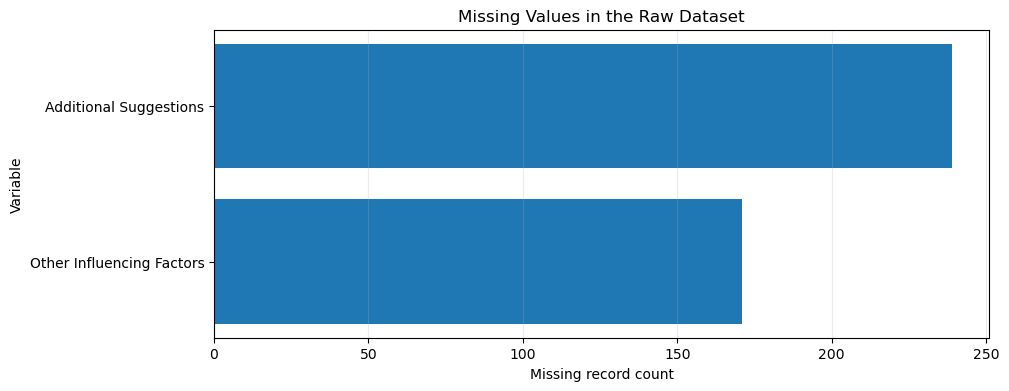

[WindowsPath('C:/Users/User/Desktop/outputs/Phase_01_Project_Setup_and_Raw_Data_Understanding/Section_01_08_Multiple_Visualization_Raw_Data/Cell_01_08_01_Visualise_Missing_Values/tables/01_08_01_visualisation_index.csv'),
 WindowsPath('C:/Users/User/Desktop/outputs/Phase_01_Project_Setup_and_Raw_Data_Understanding/Section_01_08_Multiple_Visualization_Raw_Data/Cell_01_08_01_Visualise_Missing_Values/tables/01_08_01_visualisation_index.xlsx')]

In [13]:

# Cell 1.8.1 — Visualise Missing Values

CELL_FOLDERS = create_cell_folders(
    "01_08",
    "Multiple_Visualization_Raw_Data",
    "01_08_01",
    "Visualise_Missing_Values",
)

missing_plot_data = missing_values_report[
    missing_values_report["missing_count"] > 0
].sort_values("missing_count", ascending=True)

visualisation_records = []

if missing_plot_data.empty:
    print("No missing values are available to visualise.")
else:
    figure, axis = plt.subplots(
        figsize=(10, max(4, len(missing_plot_data) * 0.35))
    )
    axis.barh(
        missing_plot_data["column_name"],
        missing_plot_data["missing_count"],
    )
    axis.set_title("Missing Values in the Raw Dataset")
    axis.set_xlabel("Missing record count")
    axis.set_ylabel("Variable")
    axis.grid(axis="x", alpha=0.25)

    figure_path = save_figure(
        figure,
        CELL_FOLDERS,
        "01_08_01_missing_values_raw_data",
    )
    plt.show()

    visualisation_records.append(
        {
            "figure_title": "Missing Values in the Raw Dataset",
            "file_path": str(figure_path),
        }
    )

missing_visualisation_index = pd.DataFrame(visualisation_records)
save_dataframe(
    missing_visualisation_index,
    CELL_FOLDERS,
    "01_08_01_visualisation_index",
)


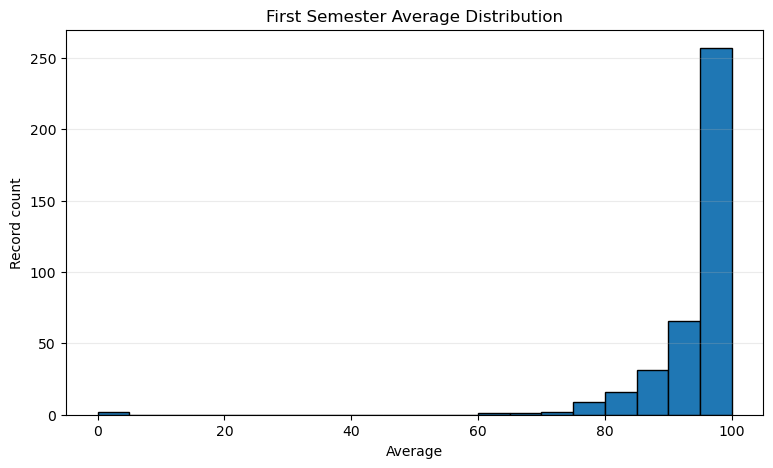

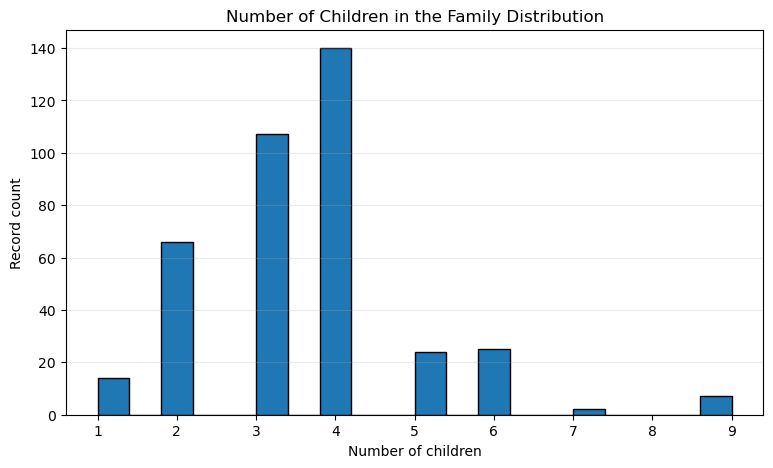

,variable,source_column,figure_title,file_path
0,First Semester Average,First Semester Average,First Semester Average Distribution,C:\Users\User\Desktop\outputs\Phase_01_Project...
1,Number of Children in the Family,Number of Family Members,Number of Children in the Family Distribution,C:\Users\User\Desktop\outputs\Phase_01_Project...


In [14]:

# Cell 1.8.2 — Visualise Raw Numerical Variables

CELL_FOLDERS = create_cell_folders(
    "01_08",
    "Multiple_Visualization_Raw_Data",
    "01_08_02",
    "Visualise_Raw_Numerical_Variables",
)

numerical_visualisation_index = []

numerical_plot_plan = [
    (
        "First Semester Average",
        ["First Semester Average"],
        "First Semester Average Distribution",
        "Average",
    ),
    (
        "Number of Children in the Family",
        ["Number of Children in the Family", "Number of Family Members"],
        "Number of Children in the Family Distribution",
        "Number of children",
    ),
]

for variable_name, possible_names, chart_title, x_label in numerical_plot_plan:
    source_column = locate_column(raw_data, possible_names)

    if source_column is None:
        print(f"Skipped: {variable_name} column was not found.")
        continue

    numeric_values = pd.to_numeric(
        raw_data[source_column]
        .astype("string")
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    ).dropna()

    if numeric_values.empty:
        print(f"Skipped: {source_column} has no usable numeric values.")
        continue

    figure, axis = plt.subplots(figsize=(9, 5))
    axis.hist(numeric_values, bins=20, edgecolor="black")
    axis.set_title(chart_title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Record count")
    axis.grid(axis="y", alpha=0.25)

    file_stem = "01_08_02_" + safe_name(variable_name).lower()
    figure_path = save_figure(figure, CELL_FOLDERS, file_stem)
    plt.show()

    numerical_visualisation_index.append(
        {
            "variable": variable_name,
            "source_column": source_column,
            "figure_title": chart_title,
            "file_path": str(figure_path),
        }
    )

numerical_visualisation_index_df = pd.DataFrame(numerical_visualisation_index)
save_dataframe(
    numerical_visualisation_index_df,
    CELL_FOLDERS,
    "01_08_02_numerical_visualisation_index",
)

display(numerical_visualisation_index_df)


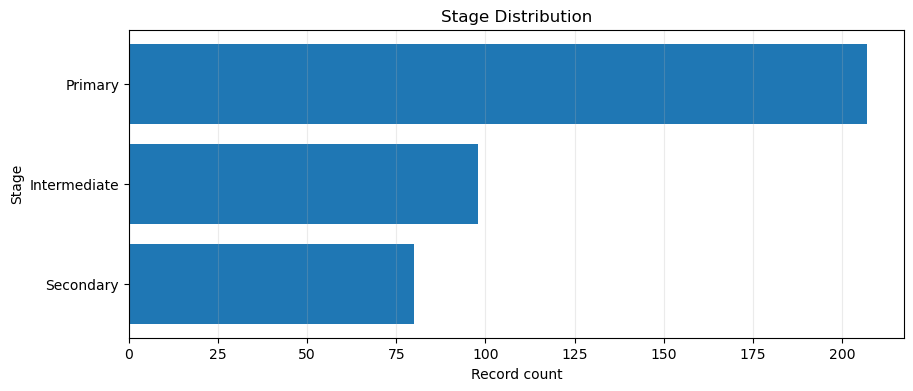

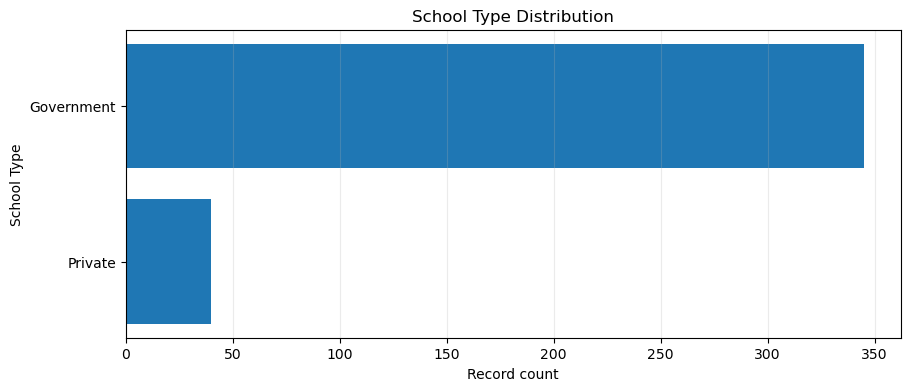

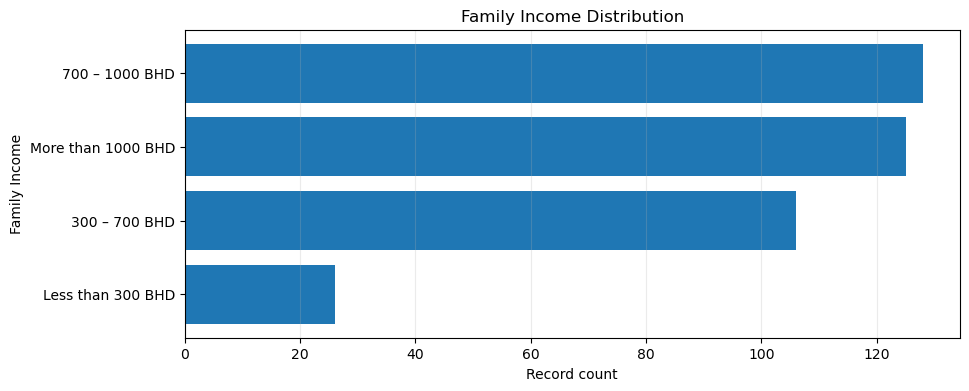

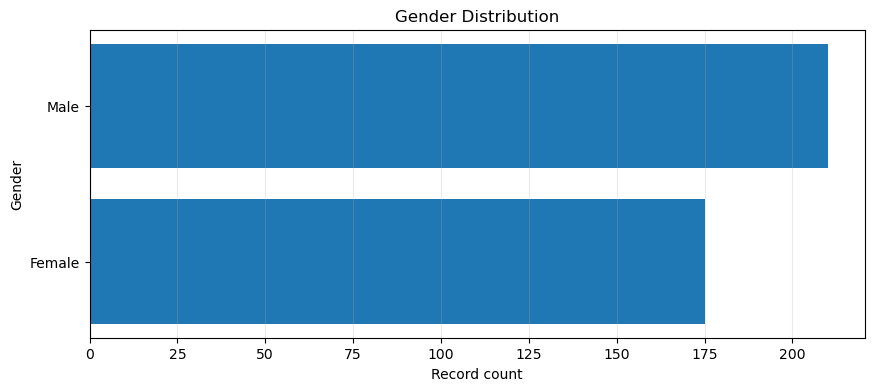

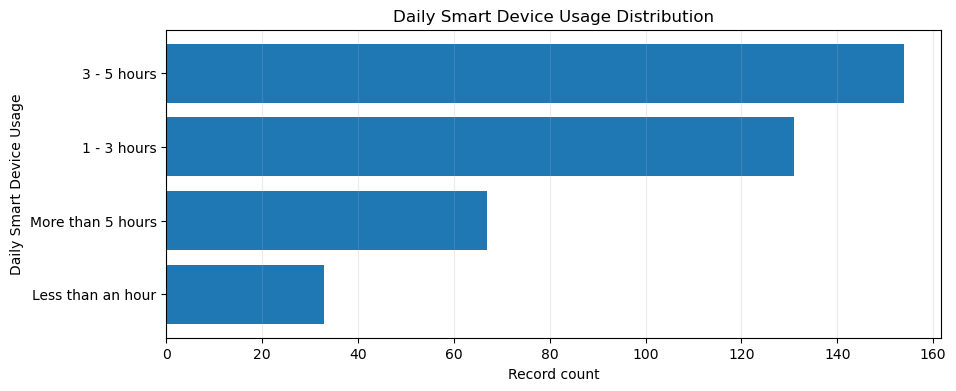

,variable,source_column,number_of_categories,file_path
0,Stage,Stage,3,C:\Users\User\Desktop\outputs\Phase_01_Project...
1,School Type,School Type,2,C:\Users\User\Desktop\outputs\Phase_01_Project...
2,Family Income,Family Income,4,C:\Users\User\Desktop\outputs\Phase_01_Project...
3,Gender,Gender,2,C:\Users\User\Desktop\outputs\Phase_01_Project...
4,Daily Smart Device Usage,Daily Smart Device Usage,4,C:\Users\User\Desktop\outputs\Phase_01_Project...


In [15]:

# Cell 1.8.3 — Visualise Raw Categorical Variables

CELL_FOLDERS = create_cell_folders(
    "01_08",
    "Multiple_Visualization_Raw_Data",
    "01_08_03",
    "Visualise_Raw_Categorical_Variables",
)

categorical_visualisation_index = []

categorical_plot_plan = [
    ("Stage", ["Stage"]),
    ("School Type", ["School Type"]),
    ("Family Income", ["Family Income"]),
    ("Gender", ["Gender"]),
    ("Daily Smart Device Usage", ["Daily Smart Device Usage"]),
]

for variable_name, possible_names in categorical_plot_plan:
    source_column = locate_column(raw_data, possible_names)

    if source_column is None:
        print(f"Skipped: {variable_name} column was not found.")
        continue

    value_counts = (
        raw_data[source_column]
        .astype("string")
        .fillna("<Missing>")
        .value_counts()
        .sort_values(ascending=True)
    )

    figure_height = max(4, len(value_counts) * 0.55)
    figure, axis = plt.subplots(figsize=(10, figure_height))
    axis.barh(value_counts.index.astype(str), value_counts.values)
    axis.set_title(f"{variable_name} Distribution")
    axis.set_xlabel("Record count")
    axis.set_ylabel(variable_name)
    axis.grid(axis="x", alpha=0.25)

    file_stem = "01_08_03_" + safe_name(variable_name).lower()
    figure_path = save_figure(figure, CELL_FOLDERS, file_stem)
    plt.show()

    categorical_visualisation_index.append(
        {
            "variable": variable_name,
            "source_column": source_column,
            "number_of_categories": len(value_counts),
            "file_path": str(figure_path),
        }
    )

categorical_visualisation_index_df = pd.DataFrame(
    categorical_visualisation_index
)
save_dataframe(
    categorical_visualisation_index_df,
    CELL_FOLDERS,
    "01_08_03_categorical_visualisation_index",
)

display(categorical_visualisation_index_df)


In [16]:

# Cell 1.8.4 — Create the Phase 1 Visualisation Catalogue

CELL_FOLDERS = create_cell_folders(
    "01_08",
    "Multiple_Visualization_Raw_Data",
    "01_08_04",
    "Create_the_Phase_1_Visualisation_Catalogue",
)

figure_files = sorted(PHASE_DIR.rglob("*.png"))

visualisation_catalogue = pd.DataFrame(
    [
        {
            "figure_number": index,
            "figure_name": path.stem,
            "relative_path": str(path.relative_to(PHASE_DIR)),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
        }
        for index, path in enumerate(figure_files, start=1)
    ]
)

save_dataframe(
    visualisation_catalogue,
    CELL_FOLDERS,
    "01_08_04_phase_1_visualisation_catalogue",
)

print(f"Total Phase 1 figures: {len(visualisation_catalogue)}")
display(visualisation_catalogue)


Total Phase 1 figures: 8


,figure_number,figure_name,relative_path,file_size_kb
0,1,01_08_01_missing_values_raw_data,Section_01_08_Multiple_Visualization_Raw_Data\...,75.60
1,2,01_08_02_first_semester_average,Section_01_08_Multiple_Visualization_Raw_Data\...,65.70
2,3,01_08_02_number_of_children_in_the_family,Section_01_08_Multiple_Visualization_Raw_Data\...,73.73
3,4,01_08_03_daily_smart_device_usage,Section_01_08_Multiple_Visualization_Raw_Data\...,89.93
4,5,01_08_03_family_income,Section_01_08_Multiple_Visualization_Raw_Data\...,79.28
5,6,01_08_03_gender,Section_01_08_Multiple_Visualization_Raw_Data\...,49.85
6,7,01_08_03_school_type,Section_01_08_Multiple_Visualization_Raw_Data\...,57.71
7,8,01_08_03_stage,Section_01_08_Multiple_Visualization_Raw_Data\...,60.79



# Section 1.9 — Export Multiple Files

**Description:** Creates a complete file manifest, a consolidated Excel workbook, a readable summary, and a ZIP archive containing all Phase 1 outputs.


In [17]:

# Cell 1.9.1 — Create Phase 1 File Manifest

CELL_FOLDERS = create_cell_folders(
    "01_09",
    "Export_Multiple_Files",
    "01_09_01",
    "Create_Phase_1_File_Manifest",
)

phase_files_before_export = sorted(
    path for path in PHASE_DIR.rglob("*") if path.is_file()
)

manifest_rows = []

for file_number, path in enumerate(phase_files_before_export, start=1):
    manifest_rows.append(
        {
            "file_number": file_number,
            "file_name": path.name,
            "file_extension": path.suffix.lower(),
            "relative_path": str(path.relative_to(PHASE_DIR)),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
            "last_modified": datetime.fromtimestamp(
                path.stat().st_mtime
            ).isoformat(),
        }
    )

phase_1_file_manifest = pd.DataFrame(manifest_rows)

save_dataframe(
    phase_1_file_manifest,
    CELL_FOLDERS,
    "01_09_01_phase_1_file_manifest",
)

display(phase_1_file_manifest)


,file_number,file_name,file_extension,relative_path,file_size_kb,last_modified
0,1,01_01_01_project_configuration.json,.json,Section_01_01_Project_Information_and_Executio...,0.58,2026-07-18T19:59:06.841081
1,2,01_02_01_library_installation_report.csv,.csv,Section_01_02_Install_Required_Libraries\Cell_...,0.17,2026-07-18T19:59:06.881369
2,3,01_02_01_library_installation_report.xlsx,.xlsx,Section_01_02_Install_Required_Libraries\Cell_...,4.92,2026-07-18T19:59:07.304347
3,4,01_03_01_reproducibility_settings.json,.json,Section_01_03_Import_Libraries_and_Reproducibi...,0.19,2026-07-18T19:59:07.834001
4,5,01_03_02_reusable_functions.csv,.csv,Section_01_03_Import_Libraries_and_Reproducibi...,0.38,2026-07-18T19:59:07.856228
5,6,01_03_02_reusable_functions.xlsx,.xlsx,Section_01_03_Import_Libraries_and_Reproducibi...,5.09,2026-07-18T19:59:07.872909
6,7,01_04_01_loading_summary.json,.json,Section_01_04_Data_Collection_and_Loading\Cell...,0.31,2026-07-18T19:59:07.910601
7,8,01_04_02_original_source_file.csv,.csv,Section_01_04_Data_Collection_and_Loading\Cell...,99.84,2026-07-18T19:58:02.566609
8,9,01_04_02_first_and_last_rows.csv,.csv,Section_01_04_Data_Collection_and_Loading\Cell...,2.73,2026-07-18T19:59:08.191323
9,10,01_04_02_first_and_last_rows.xlsx,.xlsx,Section_01_04_Data_Collection_and_Loading\Cell...,6.80,2026-07-18T19:59:08.218702


In [18]:

# Cell 1.9.2 — Export Consolidated Excel Workbook

CELL_FOLDERS = create_cell_folders(
    "01_09",
    "Export_Multiple_Files",
    "01_09_02",
    "Export_Consolidated_Excel_Workbook",
)

workbook_path = (
    CELL_FOLDERS["files"]
    / "01_09_02_phase_1_consolidated_reports.xlsx"
)

workbook_tables = {
    "Project_Config": pd.DataFrame([project_configuration]),
    "Library_Report": installation_report_df,
    "Data_Dictionary": data_dictionary,
    "Dataset_Overview": dataset_overview,
    "Column_Description": column_description,
    "Numeric_Statistics": numeric_statistics,
    "Categorical_Stats": categorical_statistics,
    "Category_Frequencies": raw_category_frequencies,
    "Missing_Values": missing_values_report,
    "Quality_Summary": quality_summary,
    "Raw_Category_Values": raw_categorical_value_report,
    "Visualisation_Index": visualisation_catalogue,
    "File_Manifest": phase_1_file_manifest,
}

with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
    for sheet_name, table in workbook_tables.items():
        table.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )

print("Consolidated workbook created:")
print(workbook_path)


Consolidated workbook created:
C:\Users\User\Desktop\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files\Cell_01_09_02_Export_Consolidated_Excel_Workbook\files\01_09_02_phase_1_consolidated_reports.xlsx


In [19]:

# Cell 1.9.3 — Export Phase Summary and ZIP Archive

import zipfile

CELL_FOLDERS = create_cell_folders(
    "01_09",
    "Export_Multiple_Files",
    "01_09_03",
    "Export_Phase_Summary_and_ZIP_Archive",
)

phase_summary = {
    "phase": "Phase 1 — Project Setup and Raw Data Understanding",
    "project_title": PROJECT_TITLE,
    "student": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "source_file": SOURCE_FILE.name,
    "raw_record_count": int(len(raw_data)),
    "raw_column_count": int(len(raw_data.columns)),
    "preprocessing_applied": False,
    "records_deleted": 0,
    "values_changed": 0,
    "figures_created": int(len(visualisation_catalogue)),
    "phase_output_directory": str(PHASE_DIR),
    "completed_at": datetime.now().isoformat(),
}

save_json_report(
    phase_summary,
    CELL_FOLDERS,
    "01_09_03_phase_1_summary",
)

summary_text = f"""
PHASE 1 COMPLETION SUMMARY
{'=' * 70}

Project:
{PROJECT_TITLE}

Student:
{STUDENT_NAME} | ID: {STUDENT_ID}

Environment:
{EXECUTION_ENVIRONMENT}

Source file:
{SOURCE_FILE.name}

Raw dataset:
- Records: {len(raw_data)}
- Columns: {len(raw_data.columns)}

Phase policy:
- Preprocessing applied: No
- Records deleted: 0
- Values changed: 0

Outputs:
- Figures created: {len(visualisation_catalogue)}
- Output directory: {PHASE_DIR}

Completed at:
{phase_summary['completed_at']}
""".strip()

summary_text_path = CELL_FOLDERS["reports"] / "01_09_03_phase_1_summary.txt"
summary_text_path.write_text(summary_text, encoding="utf-8")

zip_path = CELL_FOLDERS["files"] / "01_09_03_phase_1_complete_export.zip"

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:
    for file_path in sorted(PHASE_DIR.rglob("*")):
        if not file_path.is_file() or file_path == zip_path:
            continue
        zip_file.write(file_path, file_path.relative_to(PHASE_DIR))

print(summary_text)
print("\nZIP archive created:")
print(zip_path)


PHASE 1 COMPLETION SUMMARY

Project:
Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

Student:
Jaafar Ahmed | ID: 202508989

Environment:
ANACONDA

Source file:
questionnaire_results_en_2026-07-18_16-58-02.csv

Raw dataset:
- Records: 385
- Columns: 27

Phase policy:
- Preprocessing applied: No
- Records deleted: 0
- Values changed: 0

Outputs:
- Figures created: 8
- Output directory: C:\Users\User\Desktop\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding

Completed at:
2026-07-18T19:59:11.934429

ZIP archive created:
C:\Users\User\Desktop\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files\Cell_01_09_03_Export_Phase_Summary_and_ZIP_Archive\files\01_09_03_phase_1_complete_export.zip



# Phase 1 Completed

The raw questionnaire dataset has been loaded, preserved, documented, quality-checked, and visualised without preprocessing. Phase 2 will apply the approved cleaning and feature-preparation rules.
